# Comparing RFR3, RFR10 and the ORF benchmark

The paper's two configurations differ only in their drivers: RFR3 uses the
three that MDS uses, and RFR10 adds seven more. Its ORF benchmark is the same
random forest over the same drivers *without* the receptive limiter, so
RFR minus ORF measures what the engineered features contribute.

This notebook scores all four arms on one shared set of artificial gaps, lines
them up by gap length, draws the result, and shows how a run is put beside the
published medians of Supplementary Table S3.

One synthetic site is a software check, not evidence about the method. The
paper's evidence is a distribution across 94 FLUXNET sites; nothing here
expects this site to reproduce it. The notebook runs in a minute or two.

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

from rfrgapfill import (
    FeatureConfig,
    GapScenarioGenerator,
    benchmark_table,
    compare_to_benchmarks,
    convert_nee_to_carbon_units,
    gap_length_pivot,
    gap_length_table,
    median_across_sites,
    plot_benchmark_comparison,
    plot_gap_length_grid,
    require_orf_pairing,
    synthetic_site,
    validate_rfr,
)

# Show warnings as one line, without the path of the file that raised them.
warnings.formatwarning = lambda message, category, *args, **kwargs: (
    f"{category.__name__}: {message}\n"
)

# Series colours, always used in this order, and grey for the chart furniture.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
MUTED = "#898781"
plt.rcParams.update(
    {
        "figure.figsize": (10, 3.6),
        "axes.prop_cycle": plt.cycler(color=SERIES),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#c3c2b7",
        "axes.labelcolor": "#52514e",
        "axes.titlelocation": "left",
        "axes.grid": True,
        "grid.color": "#e1e0d9",
        "grid.linewidth": 0.6,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "lines.linewidth": 1.5,
        "legend.frameon": False,
    }
)

## 1. Four arms, one configuration

Every arm derives from one base configuration, so they differ only where
they are meant to. `as_orf()` switches off the receptive limiter and nothing
else, and `require_orf_pairing` refuses a pair that differs in anything more.

In [2]:
site = synthetic_site()
targets = list(site.targets)
qc = dict(site.qc_columns())
rfr3 = site.config(
    "RFR3",
    features=FeatureConfig(daily_statistic_strategy="rolling_available"),
    hyperparameter_grid={"n_estimators": (50,)},
    n_jobs=-1,
)
rfr10 = rfr3.replace(mode="RFR10")
arms = {"RFR3": rfr3, "RFR10": rfr10, "ORF3": rfr3.as_orf(), "ORF10": rfr10.as_orf()}

require_orf_pairing(arms["RFR3"], arms["ORF3"])
require_orf_pairing(arms["RFR10"], arms["ORF10"])
pd.DataFrame({name: {"paper faithful": arm.is_paper_faithful} for name, arm in arms.items()})

,RFR3,RFR10,ORF3,ORF10
paper faithful,True,True,False,False


## 2. Score every arm on the same gaps

Placing the gaps once and passing them to every run is what makes the arms
comparable: any difference comes from the method, not from where the gaps fell.
The warning below is expected: real outages under the gaps leave the achieved
fraction short of the 25% requested, and the package reports that rather than
adjusting it (ambiguity A7, covered in
[`02_artificial_gap_validation.ipynb`](02_artificial_gap_validation.ipynb)).

In [3]:
gaps = GapScenarioGenerator(rfr3).generate(site.frame, target=targets, qc_column=qc)
print(gaps.summary())

withheld 2282 of 12518 available observation(s) (18.2%, requested 25.0%) as 17 gap(s) under allocation_basis='missing_records': short 13 x P1DT0H0M0S (22% of records, requested 20%); long 3 x P7DT0H0M0S (33% of records, requested 30%); very_long 1 x P30DT0H0M0S (45% of records, requested 50%)


In [4]:
reports = {
    name: validate_rfr(site.frame, config=arm, targets=targets, qc_columns=qc, gaps=gaps)
    for name, arm in arms.items()
}
table = gap_length_table(list(reports.values()), site=site.site_id)
table.head()

,site,target,method,mode,gap_class,subset,units,n,n_offered,r2,slope,rmse,bias
0,SYN-Ref,H,RFR3,RFR3,all,all,W m-2,1979,2763,0.933593,0.896592,20.895228,-2.834483
1,SYN-Ref,H,RFR3,RFR3,all,daytime,W m-2,856,1152,0.857807,0.794115,27.352370,-4.930625
2,SYN-Ref,H,RFR3,RFR3,all,nighttime,W m-2,1123,1611,-0.161479,0.047279,14.111692,-1.236712
3,SYN-Ref,H,RFR3,RFR3,short,all,W m-2,452,568,0.920404,0.843931,26.712050,-6.981407
4,SYN-Ref,H,RFR3,RFR3,short,daytime,W m-2,221,269,0.811064,0.740248,34.902279,-13.586222


`gap_length_table` lines up any number of runs, and sites, in one tidy table,
with gap classes in duration order (`short` 24 h, `long` 7 d, `very_long`
30 d). It never computes a metric itself: every number came out of a
validation run. `gap_length_pivot` turns one slice into something readable.

In [5]:
pd.concat(
    {
        "R2, 30-day gaps": gap_length_pivot(table, metric="r2", gap_class="very_long"),
        "RMSE, 30-day gaps": gap_length_pivot(table, metric="rmse", gap_class="very_long"),
    },
    axis=1,
).round(3)

R2, 30-day gaps                      RMSE, 30-day gaps                  \
                  RFR3  RFR10   ORF3  ORF10              RFR3   RFR10    ORF3   
target                                                                          
H                0.935  0.947  0.930  0.949            15.367  13.839  15.643   
LE               0.617  0.622  0.562  0.626            10.132  10.071  10.412   
NEE             -0.093 -0.111 -1.213 -0.523             0.723   0.729   1.061   

                
         ORF10  
target          
H       13.412  
LE       9.631  
NEE      0.880

## 3. Skill against gap length

The paper's central question is whether skill holds up as the gap grows from
24 hours to 30 days. `plot_gap_length_grid` draws one panel per flux with a
shared y axis, straight from the table above, so the figure cannot disagree
with it.

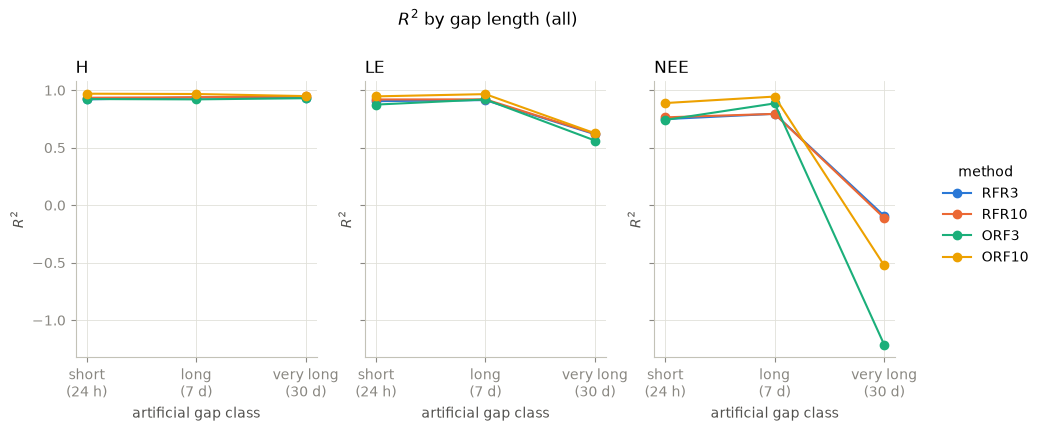

In [6]:
figure = plot_gap_length_grid(table, metric="r2", figsize=(11, 4))
figure.subplots_adjust(top=0.8, right=0.87)  # room for the title and the legend
plt.show()

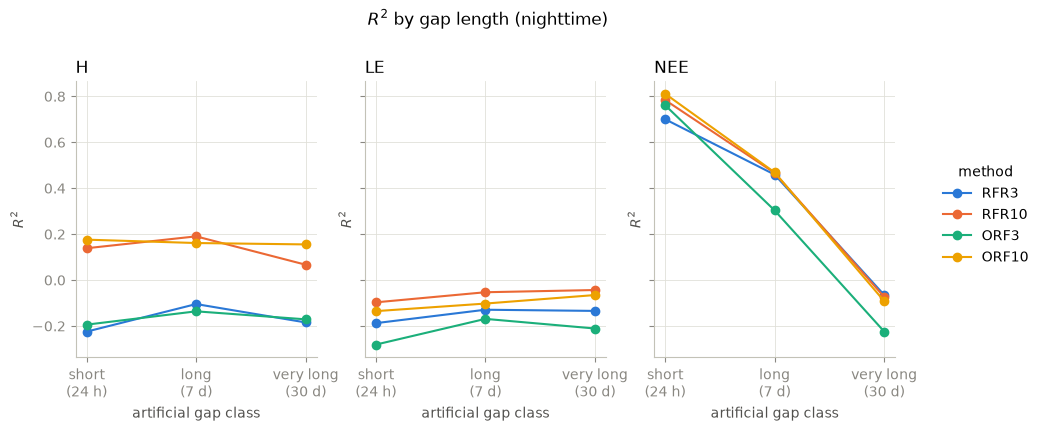

In [7]:
figure = plot_gap_length_grid(table, metric="r2", subset="nighttime", figsize=(11, 4))
figure.subplots_adjust(top=0.8, right=0.87)
plt.show()

## 4. What the receptive limiter contributes

RFR minus ORF over the same drivers, for R2 (positive is a gain) and RMSE
(negative is a gain). Nothing requires every cell to improve.

In [8]:
overall = table[table["subset"] == "all"]
# Rows in the paper's target order, gap classes in duration order.
cells = pd.MultiIndex.from_product(
    [targets, ["all", "short", "long", "very_long"]], names=["target", "gap_class"]
)


def difference(metric, method, baseline):
    wide = overall.pivot_table(index=["target", "gap_class"], columns="method", values=metric)
    return (wide[method] - wide[baseline]).reindex(cells)


pd.DataFrame(
    {
        ("R2", "RFR3 - ORF3"): difference("r2", "RFR3", "ORF3"),
        ("R2", "RFR10 - ORF10"): difference("r2", "RFR10", "ORF10"),
        ("RMSE", "RFR3 - ORF3"): difference("rmse", "RFR3", "ORF3"),
        ("RMSE", "RFR10 - ORF10"): difference("rmse", "RFR10", "ORF10"),
    }
).round(3)

R2                      RMSE              
                 RFR3 - ORF3 RFR10 - ORF10 RFR3 - ORF3 RFR10 - ORF10
target gap_class                                                    
NEE    all            -0.033        -0.116       0.357         0.756
       short           0.007        -0.124       0.194         0.766
       long           -0.090        -0.151       0.554         1.060
       very_long       1.120         0.412      -0.338        -0.152
H      all             0.007        -0.023       0.279         5.132
       short          -0.003        -0.035       1.492         8.396
       long            0.017        -0.028      -2.657         5.518
       very_long       0.004        -0.002      -0.275         0.427
LE     all             0.007        -0.033       1.836         6.108
       short           0.030        -0.027      -0.990         4.362
       long           -0.006        -0.045       0.780         7.681
       very_long       0.055        -0.004      -0.280         0.439

## 5. The published medians

Supplementary Table S3 is carried as data, every value traceable to
[`docs/supplement_benchmarks.md`](../../docs/supplement_benchmarks.md). These
are medians across the paper's 94-site subset of FLUXNET2015, valid as a
reproduction target only for a run over matching sites, inputs and
preprocessing. They are never pass/fail thresholds for one site.

In [9]:
gap_length_pivot(benchmark_table(), metric="r2", gap_class="all").round(2)

,MDS,RFR3,RFR10
target,,,
H,0.67,0.78,0.90
LE,0.63,0.75,0.85
NEE,0.72,0.78,0.84


A multi-site study aggregates its per-site scores with `median_across_sites`
and puts the result beside the published values with `compare_to_benchmarks`.
With one synthetic site the "median" is just that site, so the comparison
below shows the mechanics and nothing about the method.

NEE RMSE and bias are published in g C m-2 d-1, but this package models NEE
in µmol m-2 s-1, and the paper does not say how it converted them
(ambiguity A10). Those cells are therefore marked incomparable, not guessed:

In [10]:
medians = median_across_sites(table[table["method"].isin(["RFR3", "RFR10"])])
comparison = compare_to_benchmarks(medians)
comparison[
    (comparison["target"] == "NEE")
    & (comparison["gap_class"] == "all")
    & (comparison["subset"] == "all")
]

,target,method,gap_class,subset,metric,run,published,difference,run_units,published_units,comparable,note,site_subset,source
48,NEE,RFR3,all,all,r2,0.788226,0.78,0.008226,dimensionless,dimensionless,True,NaN,94-site complete-analysis subset,Supplementary Table S3 (mmc4.docx)
49,NEE,RFR3,all,all,slope,0.810094,0.79,0.020094,dimensionless,dimensionless,True,NaN,94-site complete-analysis subset,Supplementary Table S3 (mmc4.docx)
50,NEE,RFR3,all,all,rmse,1.818973,2.63,NaN,umol m-2 s-1,g C m-2 d-1,False,run reports rmse in umol m-2 s-1; the suppleme...,94-site complete-analysis subset,Supplementary Table S3 (mmc4.docx)
51,NEE,RFR3,all,all,bias,0.177002,-0.01,NaN,umol m-2 s-1,g C m-2 d-1,False,run reports bias in umol m-2 s-1; the suppleme...,94-site complete-analysis subset,Supplementary Table S3 (mmc4.docx)
56,NEE,RFR10,all,all,r2,0.791319,0.84,-0.048681,dimensionless,dimensionless,True,NaN,94-site complete-analysis subset,Supplementary Table S3 (mmc4.docx)
57,NEE,RFR10,all,all,slope,0.815266,0.84,-0.024734,dimensionless,dimensionless,True,NaN,94-site complete-analysis subset,Supplementary Table S3 (mmc4.docx)
58,NEE,RFR10,all,all,rmse,1.805641,2.42,NaN,umol m-2 s-1,g C m-2 d-1,False,run reports rmse in umol m-2 s-1; the suppleme...,94-site complete-analysis subset,Supplementary Table S3 (mmc4.docx)
59,NEE,RFR10,all,all,bias,0.197139,0.02,NaN,umol m-2 s-1,g C m-2 d-1,False,run reports bias in umol m-2 s-1; the suppleme...,94-site complete-analysis subset,Supplementary Table S3 (mmc4.docx)


`convert_nee_to_carbon_units` is the explicit conversion: a rate conversion,
`12.011e-6 × 86400`, documented as exactly that and not as a reconstruction of
the paper's aggregation. After it, the NEE cells compare too.

In [11]:
converted = compare_to_benchmarks(convert_nee_to_carbon_units(medians))
converted[
    (converted["target"] == "NEE")
    & (converted["gap_class"] == "all")
    & (converted["subset"] == "all")
]

,target,method,gap_class,subset,metric,run,published,difference,run_units,published_units,comparable,note,site_subset,source
48,NEE,RFR3,all,all,r2,0.788226,0.78,0.008226,dimensionless,dimensionless,True,NaN,94-site complete-analysis subset,Supplementary Table S3 (mmc4.docx)
49,NEE,RFR3,all,all,slope,0.810094,0.79,0.020094,dimensionless,dimensionless,True,NaN,94-site complete-analysis subset,Supplementary Table S3 (mmc4.docx)
50,NEE,RFR3,all,all,rmse,1.887639,2.63,-0.742361,g C m-2 d-1,g C m-2 d-1,True,NaN,94-site complete-analysis subset,Supplementary Table S3 (mmc4.docx)
51,NEE,RFR3,all,all,bias,0.183684,-0.01,0.193684,g C m-2 d-1,g C m-2 d-1,True,NaN,94-site complete-analysis subset,Supplementary Table S3 (mmc4.docx)
56,NEE,RFR10,all,all,r2,0.791319,0.84,-0.048681,dimensionless,dimensionless,True,NaN,94-site complete-analysis subset,Supplementary Table S3 (mmc4.docx)
57,NEE,RFR10,all,all,slope,0.815266,0.84,-0.024734,dimensionless,dimensionless,True,NaN,94-site complete-analysis subset,Supplementary Table S3 (mmc4.docx)
58,NEE,RFR10,all,all,rmse,1.873805,2.42,-0.546195,g C m-2 d-1,g C m-2 d-1,True,NaN,94-site complete-analysis subset,Supplementary Table S3 (mmc4.docx)
59,NEE,RFR10,all,all,bias,0.204581,0.02,0.184581,g C m-2 d-1,g C m-2 d-1,True,NaN,94-site complete-analysis subset,Supplementary Table S3 (mmc4.docx)


`plot_benchmark_comparison` draws one line per comparable cell, from the
published median to the run's value, so the length of the line is the
difference. Cells marked incomparable are left out, because a figure has
nowhere to put the caveat that goes with them.

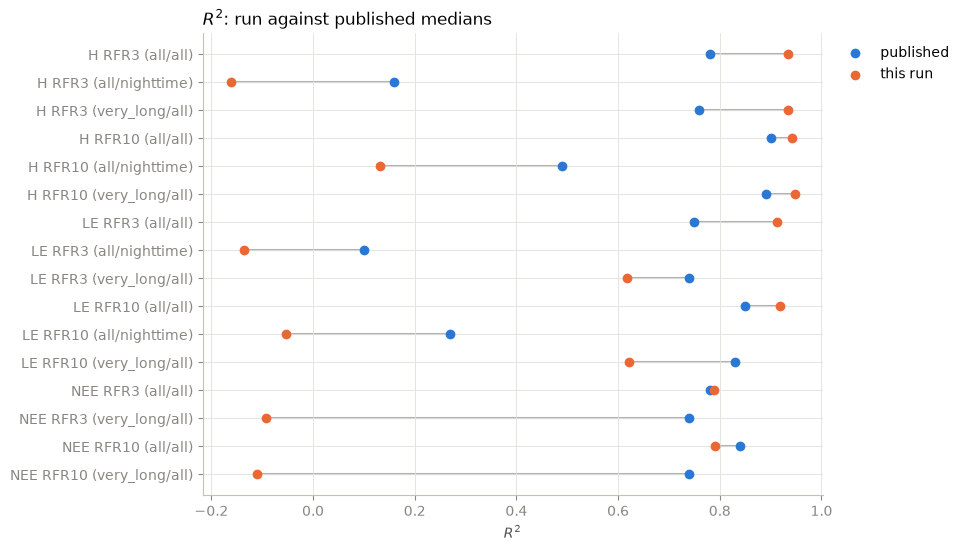

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_benchmark_comparison(converted, metric="r2", ax=ax)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))  # beside the rows, not over them
plt.show()

## Where next

- Every site is validated on its own; a multi-site study compares the
  resulting **scores**. `site_report`, `stratified_summary`,
  `method_differences` and `welch_comparison` take the same tidy table with
  more sites in it; see the "Across sites" section of
  [`docs/validation.md`](../../docs/validation.md#across-sites).
- [`04_bring_your_own_data.ipynb`](04_bring_your_own_data.ipynb) runs the
  same machinery on a FLUXNET2015-format file.